# Lab 01: Urbana Weather

---
author: Isabella Iniguez
date: September 17, 2024
embed-resources: true
---

## Introduction

In this report, we develop a model to predict the minimum daily temperature. Our primary intention for this is to reliably predict in advance when the the local Urbana Farmer’s Market should switch to indoors, as the market is only outdoors during reasonable weather.

This model can likely be used for neigboring areas or within a larger weather predicting system, but it is limited to estimating the minimum temperature of Lincoln Square (approximately around Latitude: 40.1106, Longitude: -88.2073). 

It does not consider other variables outside of the year and day of year.

## Methods

In [52]:
# imports
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

from joblib import dump

### Data

In [43]:
# load data
weather_train = pd.read_csv(
    "https://cs307.org/lab-01/data/weather-train.csv",
    index_col="date",
    parse_dates=True
)
weather_vtrain = pd.read_csv(
    "https://cs307.org/lab-01/data/weather-vtrain.csv",
    index_col="date",
    parse_dates=True
)
weather_validation = pd.read_csv(
    "https://cs307.org/lab-01/data/weather-validation.csv",
    index_col="date",
    parse_dates=True
)
weather_test = pd.read_csv(
    "https://cs307.org/lab-01/data/weather-test.csv",
    index_col="date",
    parse_dates=True
)
weather_train

,temperature_2m_min,year,month,day,day_of_year
date,,,,,
2016-01-01,-4.2715,2016,1,1,1
2016-01-02,-3.8715,2016,1,2,2
2016-01-03,-4.4715,2016,1,3,3
2016-01-04,-3.0215,2016,1,4,4
2016-01-05,-5.7715,2016,1,5,5
...,...,...,...,...,...
2021-12-27,6.9980,2021,12,27,361
2021-12-28,1.7980,2021,12,28,362
2021-12-29,2.1980,2021,12,29,363


**Data Dictionary**

The *Train* data contains one row per daily temperature reading between the years of 2016 and 2021. 

The *Validation-Train* data contains one row per daily temperature reading between the years of 2016 and 2019. 

The *Validation* data contains one row per daily temperature reading between the years of 2020 and 2021. 

The *Test* data contains one row per per daily temperature reading in 2022. 

The variables considered are:

**Response**

temperature_2m_min

-   [float64] the minimum air temperature at 2 meters above ground for the day

**Features**

year	

-   [int64] year, such as 2020

month	

-   [int64] month, such as 10 for October

day	

-   [int64] day of the month, for example 20 for January 20

day_of_year

-   [int64] day of the year, for example 100, which in non-leap years in is April 9

In [44]:
# summary statistics
cnt = weather_train[['temperature_2m_min','year']].groupby('year').agg('count').rename(columns={'temperature_2m_min':'count'})
mn = weather_train[['temperature_2m_min','year']].groupby('year').agg('mean').rename(columns={'temperature_2m_min':'temp_mean'})
sd = weather_train[['temperature_2m_min','year']].groupby('year').agg('std').rename(columns={'temperature_2m_min':'temp_std'})
year_temp_df = cnt.join(mn).join(sd)
year_temp_df

,count,temp_mean,temp_std
year,,,
2016,366,8.793391,10.274506
2017,365,8.399644,9.692305
2018,365,7.591014,11.369452
2019,365,7.229781,10.882260
2020,366,7.684612,9.383593
2021,365,8.119370,10.388489


In [45]:
mn = weather_train[['temperature_2m_min','month']].groupby('month').agg('mean').rename(columns={'temperature_2m_min':'temp_mean'})
sd = weather_train[['temperature_2m_min','month']].groupby('month').agg('std').rename(columns={'temperature_2m_min':'temp_std'})
month_temp_df = mn.join(sd)
month_temp_df

,temp_mean,temp_std
month,,
1,-4.999336,6.752006
2,-3.856209,6.760570
3,1.577277,5.615212
4,5.985861,5.615279
5,12.446632,5.342291
6,18.240583,3.492687
7,19.975933,2.632969
8,19.136954,2.889118
9,16.793083,3.815779


[Text(0.5, 0, 'Month'),
 Text(0, 0.5, 'Mean Temperature (Celcius)'),
 Text(0.5, 1.0, 'Month vs Mean Temperature'),

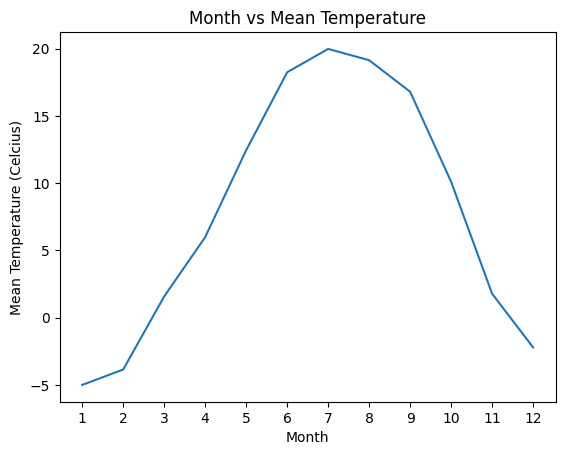

In [46]:
# visualizations

g = sns.lineplot(month_temp_df, x='month', y="temp_mean")
g.set(xlabel="Month", ylabel="Mean Temperature (Celcius)", title="Month vs Mean Temperature", xticks=range(1,13))


Breaking down the data by monthly mean temperatures, an expected and obvious trend is seen. On average, temperatures tend to peak between the months of June and September. We then see a drop following these months aligning with the start of Autumm and when the market tends to move from outdoors to indoors.

### Models

In [47]:
# process data for ML

# create X and y for train
X_train = weather_train[["year", "day_of_year"]]
y_train = weather_train["temperature_2m_min"]

# create X and y for validation-train
X_vtrain = weather_vtrain[["year", "day_of_year"]]
y_vtrain = weather_vtrain["temperature_2m_min"]

# create X and y for validation
X_validation = weather_validation[["year", "day_of_year"]]
y_validation = weather_validation["temperature_2m_min"]

# create X and y for test
X_test = weather_test[["year", "day_of_year"]]
y_test = weather_test["temperature_2m_min"]

In [48]:
# initialize models
knn001 = KNeighborsRegressor(n_neighbors=1)
knn010 = KNeighborsRegressor(n_neighbors=10)
knn100 = KNeighborsRegressor(n_neighbors=100)

# fit the models
knn001.fit(X_vtrain, y_vtrain)
knn010.fit(X_vtrain, y_vtrain)
knn100.fit(X_vtrain, y_vtrain)

# make some predictions
pred_val_001 = knn001.predict(X_validation)
pred_val_010 = knn010.predict(X_validation)
pred_val_100 = knn100.predict(X_validation)

# calculate validation RMSE
rmse_val_001 = root_mean_squared_error(y_validation, pred_val_001)
rmse_val_010 = root_mean_squared_error(y_validation, pred_val_010)
rmse_val_100 = root_mean_squared_error(y_validation, pred_val_100)

# print
print("Validation RMSE for k = 1:", rmse_val_001)
print("Validation RMSE for k = 10:", rmse_val_010)
print("Validation RMSE for k = 100:", rmse_val_100) # smallest

Validation RMSE for k = 1: 6.53635524135604
Validation RMSE for k = 10: 5.272914979181495
Validation RMSE for k = 100: 4.70645988033388


Given that the Validation RMSE for k = 100 was the smallest out of the three models, it will be our chosen model.

In [49]:
# refit to train data
knn100.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100)

## Results

In [50]:
# calculate test RMSE
rmse_test_100 = root_mean_squared_error(y_test, knn100.predict(X_test))

# print
print("Test RMSE for k = 100:", rmse_test_100)

Test RMSE for k = 100: 5.129713081159473


The selected model achieves a test accuracy of 5.1297.

## Discussion

Given our temperature values are in Celcius, a test RMSE of 5.1297 is indicative of large error and this k = 100 model not being a good predictor of temperature.

Time coheraence was maintined during data splitting by training the model on (not random) data from 2016-2021 and testing it on 2022 data. However, given this choice, the model may struggle to adapt to any trends or patterns from 2022 to now that did not exist in prior years. That is to say, predicting for 2024 will fail to take into account any changes that occured in 2022 and 2023 (perhaps due to climate change or other natural fluctuations). This can be remedied by updating the training dataset with each coming year. Given that the format of dates and metrics of temperature will not change, future data should not impact this model’s ability to perform in the future.

Despite this, using k-Nearest Neighbors (KNN) for time-series data may not make total sense because the concept of "distance" between two dates doesn't really capture temporal relationships. KNN assumes proximity to imply similarity, but in time-series data, proximity in time doesn't always mean similarity in temperature due to trends, seasonality, or sudden fluctuations. The euclidean distance on time between dates doesn't reflect the complex dependencies in temperature changes, so relying on it may have contributed to the error we found. So a possible improvement would be to use another type of model that's better suited and might provide more accurate predictions. 

### Conclusion

Given the unimpressive performance, together with the other potential issues mentioned, I do not recommend this model for use in practice at this time.

In [51]:
# serialize model
dump(knn100, "urbana-weather.joblib")

['urbana-weather.joblib']